# Cleaning and Structuring the Data

**task is to:**

- Handle missing values
- Remove duplicate or inconsistent data
- Standardize the data format

 ### Task 1: Identify Issues in the Data
Your manager provides you with an example dataset where some records are incomplete or incorrect. Here’s an example:

In [1]:
{
    "users": [
        {"id": 1, "name": "Amit", "friends": [2, 3], "liked_pages": [101]},
        {"id": 2, "name": "Priya", "friends": [1, 4], "liked_pages": [102]},
        {"id": 3, "name": "", "friends": [1], "liked_pages": [101, 103]},
        {"id": 4, "name": "Sara", "friends": [2, 2], "liked_pages": [104]},
        {"id": 5, "name": "Amit", "friends": [], "liked_pages": []}
    ],
    "pages": [
        {"id": 101, "name": "Python Developers"},
        {"id": 102, "name": "Data Science Enthusiasts"},
        {"id": 103, "name": "AI & ML Community"},
        {"id": 104, "name": "Web Dev Hub"},
        {"id": 104, "name": "Web Development"}
    ]
}

{'users': [{'id': 1, 'name': 'Amit', 'friends': [2, 3], 'liked_pages': [101]},
  {'id': 2, 'name': 'Priya', 'friends': [1, 4], 'liked_pages': [102]},
  {'id': 3, 'name': '', 'friends': [1], 'liked_pages': [101, 103]},
  {'id': 4, 'name': 'Sara', 'friends': [2, 2], 'liked_pages': [104]},
  {'id': 5, 'name': 'Amit', 'friends': [], 'liked_pages': []}],
 'pages': [{'id': 101, 'name': 'Python Developers'},
  {'id': 102, 'name': 'Data Science Enthusiasts'},
  {'id': 103, 'name': 'AI & ML Community'},
  {'id': 104, 'name': 'Web Dev Hub'},
  {'id': 104, 'name': 'Web Development'}]}

### Task 2: Clean the Data
We will:

- Remove users with missing names.
- Remove duplicate friend entries.
- Remove inactive users (users with no friends and no liked pages).
- Deduplicate pages based on IDs.

In [12]:
import json


def clean_data(data):
    # Remove users with missing names
    data["users"] = [
        user for user in data["users"]
        if user["name"].strip()
    ]

    # Remove duplicate friend names
    for user in data["users"]:
        user["friends"] = list(set(user["friends"]))

    # Remove inactive users
    data["users"] = [
        user for user in data["users"]
        if user["friends"] or user["liked_pages"]
    ]

    # Remove duplicate pages
    unique_pages = {}
    for page in data["pages"]:
        unique_pages[page["id"]] = page

    data["pages"] = list(unique_pages.values())

    return data


# Load the data
with open("data2.json", "r") as file:
    data = json.load(file)

# Clean the data
cleaned_data = clean_data(data)

# Save cleaned data
with open("cleaned_data.json", "w") as file:
    json.dump(cleaned_data, file, indent=4)

print("Data has been successfully cleaned")

Data has been successfully cleaned


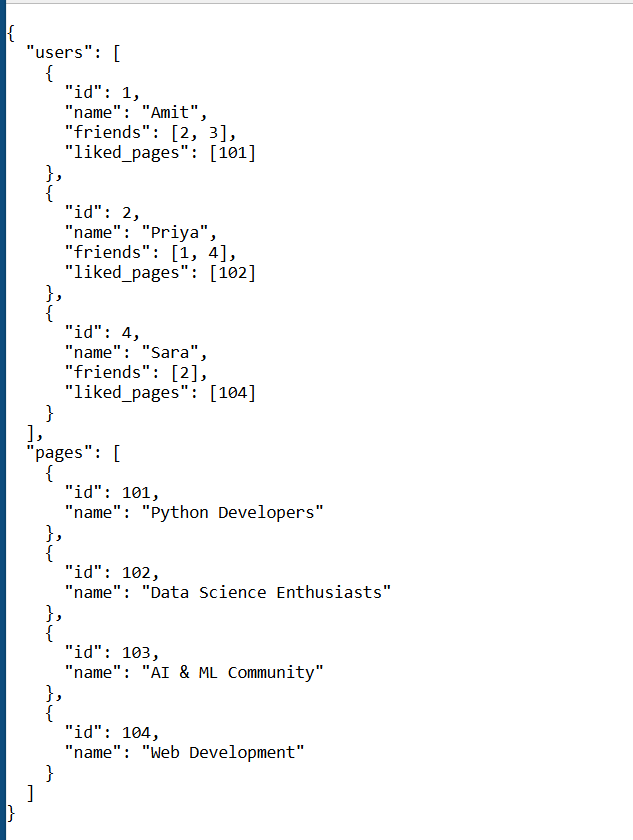